# Comparison of Gene Expression PTRs with Chromatin PTRs

April 15, 2024

Goal: Determine if there is a pattern of difference between peak cycling chromatin and peak cycling gene expression.


Analyze the difference in timing between peak and trough gene expression with peak and trough promoter occupancy.

Eventually, we can explore other measures of the chromatin like nucleosome positioning.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Polar Plot

Goal: Classify genes by their peak and trough gene expression
    
Separately for Mother and Daughter Cells

Output:
1. Time and phase of peak gene expression
2. Time and phase of trough gene expression


In [2]:
from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()

In [3]:
# Refactored to use min max values rather than peak and trough values
# todo: indices of 225 do not have a phase and need to be fixed

ge_analysis.compute_ptr_maxmins_tps()

In [4]:
ge_analysis.ptrs_min_maxs.head(2)

,mother_ptr,daughter_ptr,ptr,min_value,min_f_idx,min_tp,min_phase,max_value,max_f_idx,max_tp,max_phase
orf_name,,,,,,,,,,,
YAL067W-A,1.000799,1.003462,1.001686,4.436323733130215,127,-14.6021,D_G1,4.462289453606121,49,-28.0,C_G1
YAL067C,1.270735,3.001155,1.692257,8.653574920824855e-05,142,-3.4408,D_G1,10.387151140225065,174,13.9203,D_S


In [5]:
dse_genes = ['DSE1', 'DSE2', 'DSE3', 'DSE4']
xin_dg1_genes = ['ASH1','EGT2','AMN1','PRY3','SCW11','CTS1']

Text(0.5, 1.0, 'Gene expression PTR per cell-cycle phase')

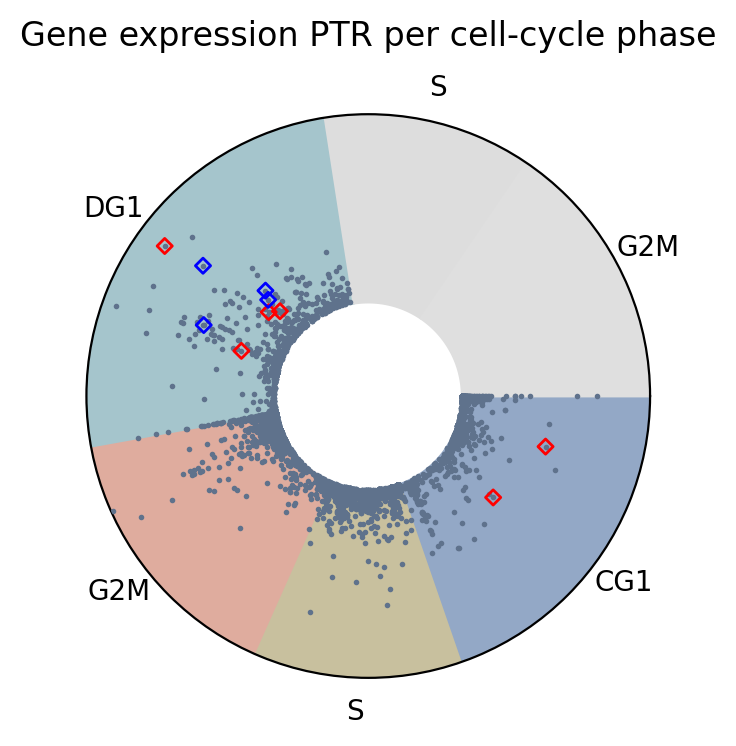

In [17]:
from src.PolarPlotter import PolarPlotter

genes_mapping = {'red': xin_dg1_genes, 'blue': dse_genes}

polar_plotter = PolarPlotter()
ge_ptr_tp_rad_df = polar_plotter.plot_scatter_polar_full(ge_analysis.ptrs_min_maxs, 
    selected_genes_mapping=genes_mapping, ylim=(0.5, 2))
plt.title("Gene expression PTR per cell-cycle phase", pad=10)

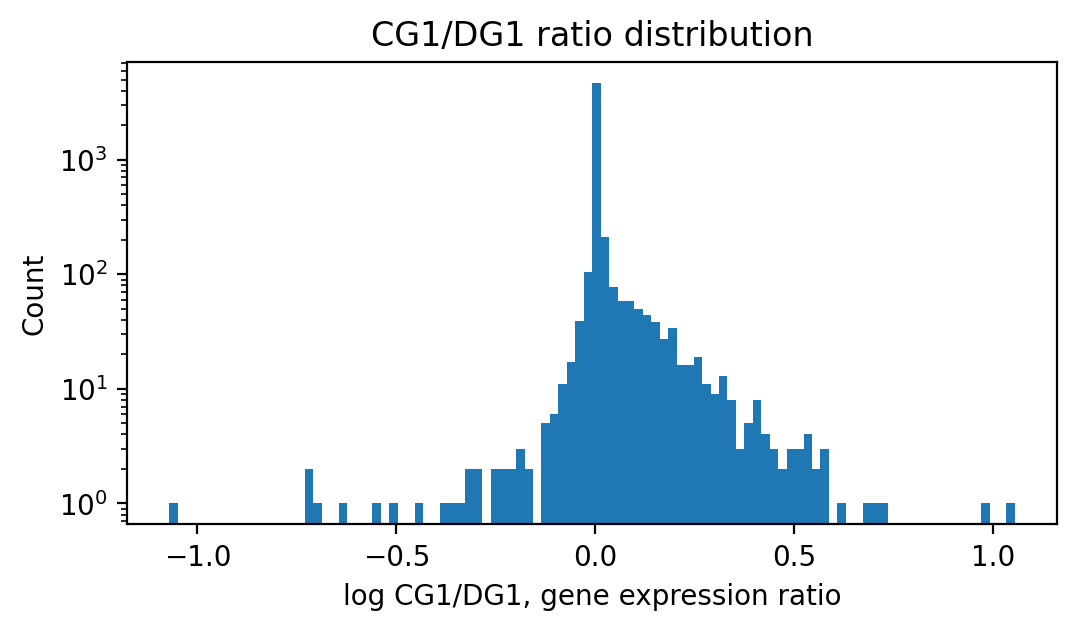

In [16]:
ge_analysis.plot_cg1_dg1_ratio()

# When setting the beta parameter, do we artificially place high PTR genes in DG1?
# How do we know there could be an identifiability problem? Do we overfit for putting the 
# DSE genes in DG1?


In [10]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)

In [11]:
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.007
1001/5574 - 00:00:05.306
2001/5574 - 00:00:10.822
3001/5574 - 00:00:16.420
4001/5574 - 00:00:22.499
5001/5574 - 00:00:28.488


In [12]:
promoter_analysis.correct_f_images_by_strand()

In [13]:
promoter_analysis.compute_small_fragments_promoter_occupancy()

In [14]:
promoter_analysis.compute_ptr_min_maxes()

Text(0.5, 1.0, 'Promoter occupancy PTR per cell-cycle phase')

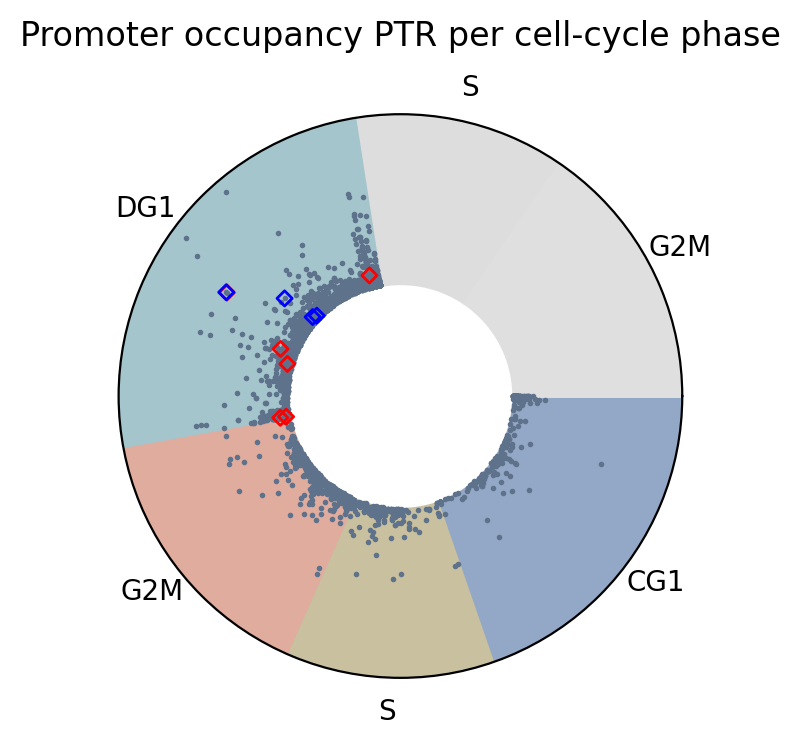

In [18]:
from src.PolarPlotter import PolarPlotter

polar_plotter = PolarPlotter()
prom_ptr_tp_rad_df = polar_plotter.plot_scatter_polar_full(promoter_analysis.promoter_min_maxs, 
    selected_genes_mapping=genes_mapping, ylim=(-5, 10))
plt.title("Promoter occupancy PTR per cell-cycle phase", pad=10)


In [19]:
from src.TimeDeltaAnalysis import TimeDeltaAnalysis

time_delta_analysis = TimeDeltaAnalysis(ge_analysis, promoter_analysis)

In [20]:
time_delta_analysis.join_analyses_compute_deltas()

In [21]:
time_delta_analysis.set_thresholds()

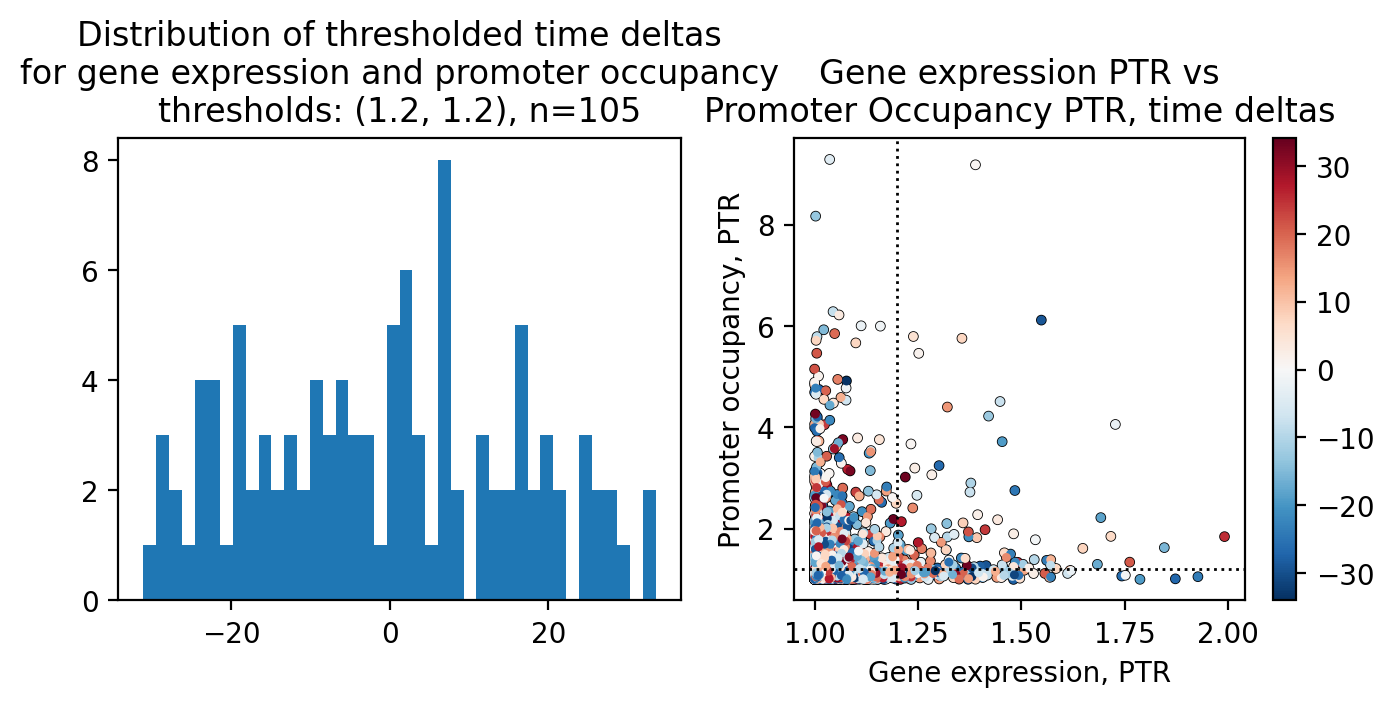

In [22]:
time_delta_analysis.plot_delta_distribution()

In [26]:
# For a specific gene example where the PTR is high for both promoter occupancy
# and gene expression, let's plot the locus and some additional information that can convey the 
# time delta information

geneset = ge_analysis.geneset

# Skip any CG1-DG1 peak genes, as those may be an identifiability model change in the future
time_delta_analysis.selected_ge_prom_diff_df.sort_values('ptr_prom').join(geneset[['gene']])


,ptr_ge,max_tp_ge,max_phase_ge,ptr_prom,max_tp_prom,max_phase_prom,min_case,signed_abs_min,gene
orf_name,,,,,,,,,
YDR374C,1.223616,39.6862,D_G2M,1.200629,-13.1139,D_G1,1,-15.3913,YDR374C
YBR161W,1.204460,-2.6061,C_G1,1.204287,-3.4408,D_G1,0,0.8347,CSH1
YKR077W,1.370710,-24.2752,D_G1,1.207740,-17.5784,D_G1,0,-6.6968,MSA2
YER053C-A,1.282239,-28.0,C_G1,1.213552,-14.6021,D_G1,0,-13.3979,YER053C-A
YBR092C,1.584083,39.6862,D_G2M,1.216137,32.6132,D_G2M,0,7.0730,PHO3
...,...,...,...,...,...,...,...,...,...
YFL051C,1.251889,34.1288,D_G2M,5.459991,-35.4364,D_G1,1,1.3738,YFL051C
YJL078C,1.356352,-12.4174,C_G1,5.756314,-19.8107,D_G1,0,7.3933,PRY3
YER124C,1.238910,-14.6021,D_G1,5.792067,-19.8107,D_G1,0,5.2086,DSE1


In [77]:
from src.TimeDeltaAnalysis import TracePlotter

tracer_plotter = TracePlotter(ge_analysis, promoter_analysis)

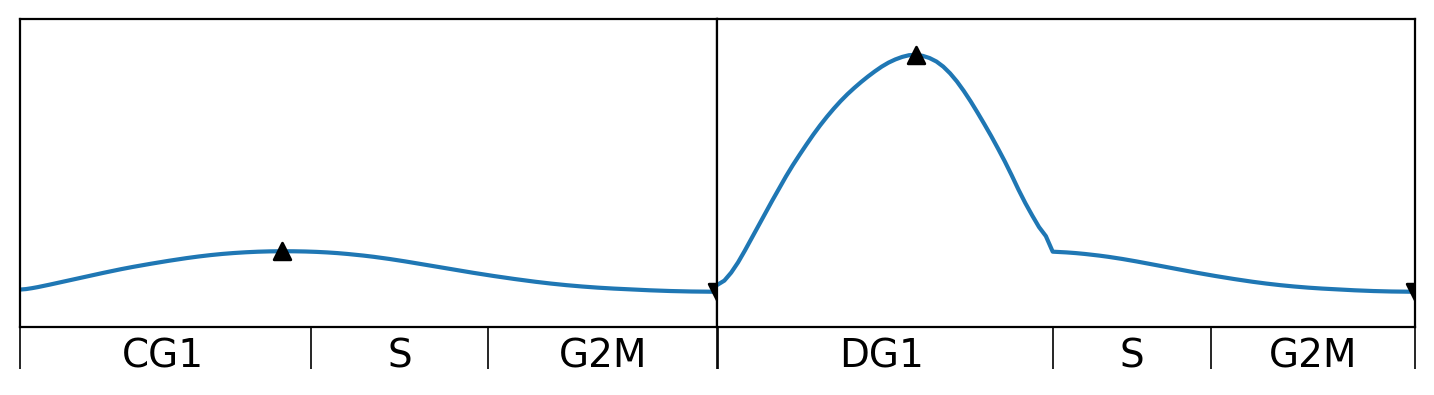

In [204]:
tracer_plotter.plot_time_delta_curves(orf_name)